# Deutsch-Jozsa 算法

量子Deutsch-Jozsa算法是一个量子算法，由David Deutsch和Richard Jozsa在1992年提出。这个算法是量子计算的早期成果之一，它展示了量子计算在某些问题上相对于经典计算的潜在优势[1]。Deutsch-Jozsa算法的目的是解决以下问题：

## Deutsch-Jozsa 问题

给定一个隐藏的布尔函数 $f$ ，它接受一个比特串作为输入，并返回 $0$ 或 $1$ ，即：

$$
f(\{x_0,x_1,x_2,...\}) \rightarrow 0 \textrm{ 或 } 1 \textrm{ ，其中 } x_n \textrm{ 为 } 0 \textrm{ 或 } 1
$$

已知该布尔函数要么是均衡的，要么是常数的。常数函数对任意输入都返回全 $0$ 或全 $1$ ，而均衡函数对一半输入返回 $0$ ，对另一半返回 $1$ 。我们的任务是判断给定函数是均衡还是常数。

注意，Deutsch-Jozsa 问题是单比特 Deutsch 问题的 $n$ 比特扩展。

### 经典解法

在最优情况下，经典算法只需查询两次就能判断隐藏的布尔函数 $f(x)$ 是否均衡：

例如，如果我们得到 $f(0,0,0,...)\rightarrow 0$ 且 $f(1,0,0,...) \rightarrow 1$ ，那么可以确定函数是均衡的，因为我们获得了两个不同的输出。

在最坏情况下，如果我们不断尝试不同的输入但总是得到相同的输出，那么为了确定 $f(x)$ 是常数，我们需要检查一半以上的所有可能输入。由于可能的输入总数为 $2^n$ ，这意味着在最坏情况下，我们需要尝试 $2^{n-1}+1$ 个输入才能确定 $f(x)$ 是常数。例如，对于 $4$ 比特串，如果我们检查了 $16$ 个可能组合中的 $8$ 个，都得到 $0$ ，仍然有可能第 $9$ 个输入返回 $1$ 且 $f(x)$是均衡的。从概率上讲，这是一个非常不可能的事件。事实上，如果我们连续得到相同的结果，可以将函数为常数的概率表示为输入次数 $k$ 的函数：

$$ P_\textrm{常数}(k) = 1 - \frac{1}{2^{k-1}} \qquad \textrm{对于 } 1 < k \leq 2^{n-1}$$

现实中，如果我们有 x% 的把握，可以选择提前终止经典算法。但如果想要 100% 确定，就需要检查 $2^{n-1}+1$ 个输入。

### 量子解法

使用量子计算机，只要我们将函数 $f$ 实现为将态 $\vert x \rangle \vert y \rangle $ 映射到 $ \vert x \rangle \vert y \oplus f(x) \rangle$ 的量子谕言机($\oplus$ 表示模 $2$ 加法)，就能以 100% 的把握在只调用函数 $f$ 一次后解决该问题。下面是 Deutsch-Jozsa 算法的通用线路。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/deutsch_steps.png" width="40%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>


现在，让我们来看算法的步骤：

1. 准备两个量子寄存器。第一个是初始化为 $\vert0\rangle$ 的 $n$ -比特寄存器，第二个是初始化为 $\vert1\rangle$ 的单比特寄存器:   $$\vert \psi_0 \rangle = \vert0\rangle^{\otimes n} \vert 1\rangle$$

2. 对每个比特应用 Hadamard 门:

$$\vert \psi_1 \rangle = \frac{1}{\sqrt{2^{n+1}}}\sum_{x=0}^{2^n-1} \vert x\rangle \left(\vert0\rangle - \vert1\rangle \right)$$

3. 应用量子oracle $\vert x\rangle \vert y\rangle$ 到 $\vert x\rangle \vert y \oplus f(x)\rangle$:

$$   \begin{aligned}   \lvert \psi_2 \rangle   & = \frac{1}{\sqrt{2^{n+1}}}\sum_{x=0}^{2^n-1} \vert x\rangle (\vert f(x)\rangle - \vert 1 \oplus f(x)\rangle) \\   & = \frac{1}{\sqrt{2^{n+1}}}\sum_{x=0}^{2^n-1}(-1)^{f(x)}\vert x\rangle ( \vert0\rangle - \vert1\rangle )   \end{aligned}   $$

因为对每个 $x$，  $f(x)$ 要么是 $0$ 要么是 $1$。

4. 此时可以忽略第二个单比特寄存器。对第一个寄存器的每个比特应用 Hadamard 门:

    $$
    \begin{aligned}
        \lvert \psi_3 \rangle
            & = \frac{1}{2^n}\sum_{x=0}^{2^n-1}(-1)^{f(x)}
                \left[ \sum_{y=0}^{2^n-1}(-1)^{x \cdot y}
                \vert y \rangle \right] \\
            & = \frac{1}{2^n}\sum_{y=0}^{2^n-1}
                \left[ \sum_{x=0}^{2^n-1}(-1)^{f(x)}(-1)^{x \cdot y} \right]
                \vert y \rangle
    \end{aligned}
    $$

    其中 $x \cdot y = x_0y_0 \oplus x_1y_1 \oplus \ldots \oplus x_{n-1}y_{n-1}$ 是按位乘积的和。

5. 测量第一个寄存器。注意到测量 $\vert 0 \rangle ^{\otimes n} = \lvert \frac{1}{2^n}\sum_{x=0}^{2^n-1}(-1)^{f(x)} \rvert^2$ 的概率，如果 $f(x)$ 是常数则为 $1$，如果 $f(x)$ 是均衡的则为 $0$ 。



## 创建量子oracle

- **常数的量子oracle**

当量子oracle为*常数*时,它对输入的量子比特没有影响（相差一个全局相位），查询谕言机前后的量子态是相同的。由于 H 门是自己的逆，在第 4 步中我们逆转第 2 步以获得第一个寄存器的初始量子态 $\vert00\dots0\rangle$ 。

$$
H^{\otimes n}\begin{bmatrix} 1 \\ 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}
=
\tfrac{1}{\sqrt{2^n}}\begin{bmatrix} 1 \\ 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}
\quad \xrightarrow{\text{after } U_f} \quad
H^{\otimes n}\tfrac{1}{\sqrt{2^n}}\begin{bmatrix} 1 \\ 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}
=
\begin{bmatrix} 1 \\ 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}
$$

- **均衡的量子oracle**

步骤2完成后，我们的输入寄存器处于计算基的所有态的等概率叠加态。当oracle是*均衡*时，相位反冲会为其中一半的态添加负相位：

$$
U_f \tfrac{1}{\sqrt{2^n}}\begin{bmatrix} 1 \\ 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}
=
\tfrac{1}{\sqrt{2^n}}\begin{bmatrix} -1 \\ 1 \\ -1 \\ \vdots \\ 1 \end{bmatrix}
$$

查询oracle前后的量子态是正交的。因此，在步骤4中应用H门时，我们必须得到一个与$|00\dots 0\rangle$正交的量子态。这意味着我们永远不会测量到全零态。


让我们看看创建量子oracle的一些不同方法。

对于常数函数，很简单：

$\qquad$ 1. 如果f(x) = 0，则对寄存器2中的量子比特应用 $I$ 门。

$\qquad$ 2. 如果f(x) = 1，则对寄存器2中的量子比特应用 $X$ 门。

对于均衡函数，我们可以创建许多不同的电路。我们可以保证电路是均衡的一种方法是，对寄存器1中的每个量子比特执行CNOT，以寄存器2中的量子比特作为目标。例如：

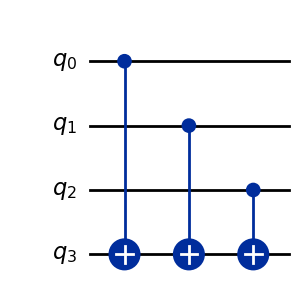

In [180]:
import numpy as np

import deepquantum as dq

cir = dq.QubitCircuit(4)

cir.cnot(0, 3)
cir.cnot(1, 3)
cir.cnot(2, 3)

cir.draw()

在上图中，顶部三个量子比特构成输入寄存器，底部量子比特是输出寄存器。我们可以在下表中看到哪些输入态对应哪些输出：

$$
\begin{array}{|c|c|}
\hline
\text{输出为0的输入态} & \text{输出为1的输入态} \\
\hline
000 & 001 \\
011 & 100 \\
101 & 010 \\
110 & 111 \\
\hline
\end{array}
$$

我们可以通过将选定的控制位包裹在X门中来改变结果，同时保持它们的均衡性。例如，看下面的线路及其结果表：

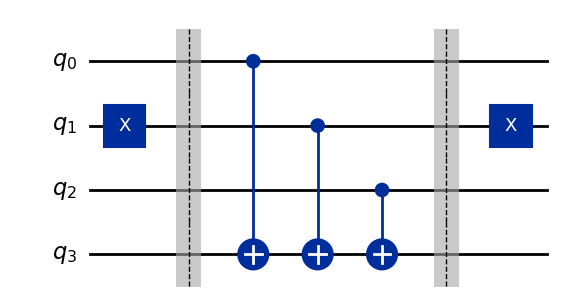

In [181]:
cir = dq.QubitCircuit(4)

cir.x(1)
cir.barrier()

cir.cnot(0, 3)
cir.cnot(1, 3)
cir.cnot(2, 3)

cir.barrier()
cir.x(1)

cir.draw()

$$
\begin{array}{|c|c|}
\hline
\text{输出为0的输入态} & \text{输出为1的输入态} \\
\hline
001 & 000 \\
010 & 011 \\
100 & 101 \\
111 & 110 \\
\hline
\end{array}
$$

## 代码实现

现在让我们以一个三比特函数为例，使用DeepQuantum实现 Deutsch-Jozsa 算法，分别构建常数和平衡的 oracle。

### 常数 Oracle
首先创建一个常数 oracle，在这种情况下，输入对输出没有影响，所以我们随机将输出量子比特设置为0或1：

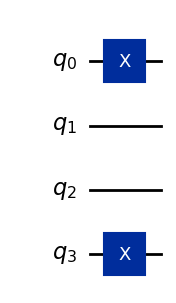

In [182]:
cir = dq.QubitCircuit(4)

for i in range(4):
    output = np.random.randint(2)
    if output == 1:
        cir.x(i)

cir.draw()

### 平衡 Oracle

创建一个平衡的 oracle。我们可以通过使用每个输入量子比特作为控制位，输出比特作为目标位，执行 CNOT 门来创建平衡 oracle。我们可以通过用 X 门操控一些控制位来改变产生0或1的输入状态。首先选择一个长度为`n`的二进制字符串，用于指示要操作哪些控制位：

有了这个字符串，我们就可以将其作为放置 X 门的依据。对于电路中的每个量子比特，如果`b_str`中对应的数字为`1`，则放置一个 X 门，如果数字为`0`则不做任何操作。

接下来，执行受控非门，以每个输入量子比特作为控制位，输出量子比特作为目标位：

最后，重复前面两个单元的代码，完成用 X 门控制位的操作：

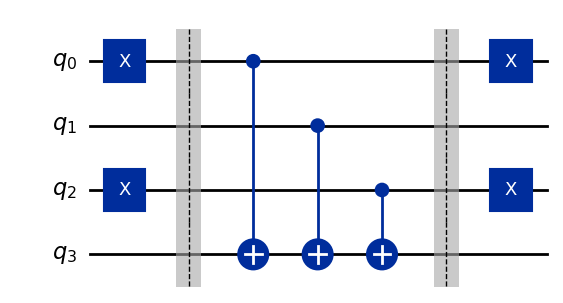

In [183]:
cir = dq.QubitCircuit(4)
b_str = '101'

# Place X-gates
for qubit in range(len(b_str)):
    if b_str[qubit] == '1':
        cir.x(qubit)

cir.barrier()

cir.cnot(0, 3)
cir.cnot(1, 3)
cir.cnot(2, 3)

cir.barrier()
for qubit in range(len(b_str)):
    if b_str[qubit] == '1':
        cir.x(qubit)

cir.draw()

至此我们已经创建了一个平衡 oracle 剩下要做的就是看 Deutsch-Jozsa 算法是否可以解决它。

### 完整算法

现在把所有步骤整合在一起。算法的第一步是将输入量子比特初始化为态 $|{+}\rangle$，输出量子比特初始化为态 $|{-}\rangle$：

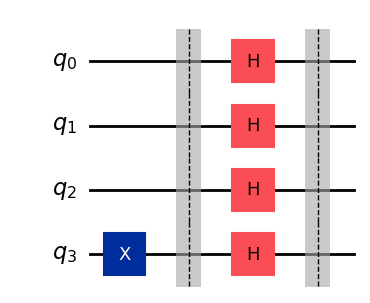

In [184]:
cir = dq.QubitCircuit(4)
cir.x(3)
cir.barrier()
cir.hlayer()
cir.barrier()
cir.draw()

接下来，应用前面创建的`cir`：

最后，对 $n$ 个输入量子比特执行 H 门，并测量输入寄存器：



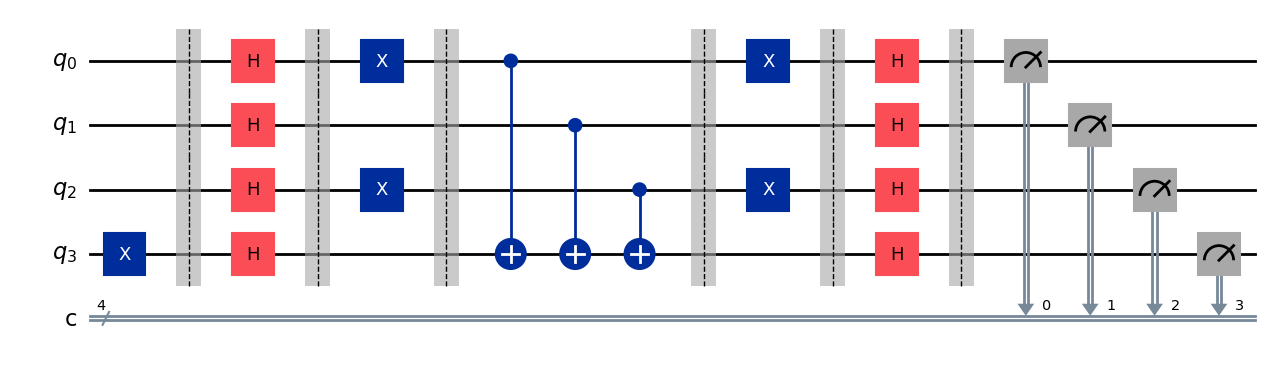

In [185]:
cir = dq.QubitCircuit(4)
cir.x(3)
cir.barrier()
cir.hlayer()
cir.barrier()
cir.draw()
b_str = '101'
for qubit in range(len(b_str)):
    if b_str[qubit] == '1':
        cir.x(qubit)

cir.barrier()

cir.cnot(0, 3)
cir.cnot(1, 3)
cir.cnot(2, 3)

cir.barrier()
for qubit in range(len(b_str)):
    if b_str[qubit] == '1':
        cir.x(qubit)

cir.barrier()
cir.hlayer()
cir.barrier()
cir.measure()
cir.draw()

来看输出结果:

In [186]:
cir()
cir.measure()

{'1111': 1024}

从上面的结果可以看出,测量得到`000`的概率为0%。这正确预测了函数是平衡的。

## 附录

[1] Deutsch D, Jozsa R. Rapid solution of problems by quantum computation[J]. Proceedings of the Royal Society of London. Series A: Mathematical and Physical Sciences, 1992, 439(1907): 553-558.